# Complete Index Code

## Extracting Daily Rainfall from NetCDF Files with GADM 

In [1]:
# -------------------------------------------------------------------
# STEP 0: SETUP AND LIBRARIES
# -------------------------------------------------------------------
import pandas as pd
import geopandas as gpd
import xarray as xr
import rioxarray 
import numpy as np
import os # We'll use os to join file paths

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# -------------------------------------------------------------------
# !!! IMPORTANT: SET YOUR VARIABLES HERE !!!
# -------------------------------------------------------------------
# --- 1. File Paths ---
GEOJSON_FILE = r"C:\Users\Acer\Desktop\Rainfall Index Derivatives\Data\GADM\gadm41_IND_2.json"
# Folder containing your .nc files
NETCDF_FOLDER = r"C:\Users\Acer\Desktop\Rainfall Index Derivatives\Data\Gridded Rainfall in India"
OUTPUT_FILE = 'kanker_daily_rain_1997-2024.csv'

# --- 2. Data Assumptions (YOU MUST CHECK THESE) ---
# This is how your files are named. 
# The {year} will be replaced by 1997, 1998, etc.
# FOR EXAMPLE: if your file is "rain_1997.nc", use "rain_{year}.nc"
FILE_NAME_PATTERN = 'RF25_ind{year}_rfp25.nc' 

RAIN_VAR_NAME = 'RAINFALL'  # Variable name for rainfall in your NetCDF
STATE_COL = 'NAME_1'      # GADM column name for State
DISTRICT_COL = 'NAME_2'   # GADM column name for District
STATE_NAME = 'Chhattisgarh'
DISTRICT_NAME = 'UttarBastarKanker'  # Confirmed new district

# --- 3. Time Range ---
# The years your NetCDF files cover
START_YEAR = 1997
END_YEAR = 2024

In [3]:
# -------------------------------------------------------------------
# STEP 1: LOAD AND PREPARE KANKER GEOMETRY
# -------------------------------------------------------------------
print(f"Loading GeoJSON: {GEOJSON_FILE}...")
all_india_gdf = gpd.read_file(GEOJSON_FILE)

print(f"Filtering for District: {DISTRICT_NAME}, State: {STATE_NAME}...")
kanker_gdf = all_india_gdf[
    (all_india_gdf[DISTRICT_COL] == DISTRICT_NAME) & 
    (all_india_gdf[STATE_COL] == STATE_NAME)
]

if kanker_gdf.empty:
    print(f"--- ERROR: Could not find district '{DISTRICT_NAME}' in state '{STATE_NAME}' ---")
else:
    print("Successfully isolated Kanker district geometry.")
    # Ensure CRS is set, re-project later if needed
    if kanker_gdf.crs is None:
        kanker_gdf.set_crs("EPSG:4326", inplace=True)

Loading GeoJSON: C:\Users\Acer\Desktop\Rainfall Index Derivatives\Data\GADM\gadm41_IND_2.json...
Filtering for District: UttarBastarKanker, State: Chhattisgarh...
Successfully isolated Kanker district geometry.


In [4]:
# -------------------------------------------------------------------
# STEP 2: LOOP, LOAD, AND PROCESS EACH YEARLY NETCDF FILE
# -------------------------------------------------------------------
# print(f"Starting to process files from {START_YEAR} to {END_YEAR}...")
all_years_data = [] # This list will hold all the yearly DataFrames

# Get the CRS from the Kanker GeoDataFrame *before* the loop
# We will force the NetCDF CRS to match this.
target_crs = kanker_gdf.crs

for year in range(START_YEAR, END_YEAR + 1):
    
    # --- A. Construct file path ---
    file_name = FILE_NAME_PATTERN.format(year=year)
    file_path = os.path.join(NETCDF_FOLDER, file_name)
    
    print(f"\nProcessing: {file_name}...")
    
    try:
        # --- B. Load one year's NetCDF file ---
        with xr.open_dataset(file_path) as ds:
            # Isolate the rain variable
            rain_data = ds[RAIN_VAR_NAME]
            
            # --- C. Set CRS and Clip ---
            # Set the spatial dimensions and CRS (assuming WGS84)
            rain_data = rain_data.rio.set_spatial_dims(x_dim='LONGITUDE', y_dim='LATITUDE', inplace=True)
            rain_data.rio.write_crs("EPSG:4326", inplace=True)
            
            # Re-project NetCDF to match the GeoJSON's CRS if they don't match
            if rain_data.rio.crs != target_crs:
                rain_data = rain_data.rio.reproject(target_crs)
            
            # Clip the data
            kanker_rain_year = rain_data.rio.clip(kanker_gdf.geometry, all_touched=True)
            
            # --- D. Calculate spatial mean ---
            spatial_dims = [rain_data.rio.x_dim, rain_data.rio.y_dim]
            kanker_daily_mean = kanker_rain_year.mean(dim=spatial_dims, skipna=True)
            
            # --- E. Convert to DataFrame and append ---
            df_year = kanker_daily_mean.to_dataframe()
            all_years_data.append(df_year)
            
            print(f"Successfully processed and appended {year}.")

    except FileNotFoundError:
        print(f"--- WARNING: File not found: {file_path} --- Skipping this year.")
    except Exception as e:
        print(f"--- ERROR processing {file_name}: {e} --- Skipping this year.")

print("\nFile processing loop finished.")


Processing: RF25_ind1997_rfp25.nc...
Successfully processed and appended 1997.

Processing: RF25_ind1998_rfp25.nc...
Successfully processed and appended 1998.

Processing: RF25_ind1999_rfp25.nc...
Successfully processed and appended 1999.

Processing: RF25_ind2000_rfp25.nc...
Successfully processed and appended 2000.

Processing: RF25_ind2001_rfp25.nc...
Successfully processed and appended 2001.

Processing: RF25_ind2002_rfp25.nc...
Successfully processed and appended 2002.

Processing: RF25_ind2003_rfp25.nc...
Successfully processed and appended 2003.

Processing: RF25_ind2004_rfp25.nc...
Successfully processed and appended 2004.

Processing: RF25_ind2005_rfp25.nc...
Successfully processed and appended 2005.

Processing: RF25_ind2006_rfp25.nc...
Successfully processed and appended 2006.

Processing: RF25_ind2007_rfp25.nc...
Successfully processed and appended 2007.

Processing: RF25_ind2008_rfp25.nc...
Successfully processed and appended 2008.

Processing: RF25_ind2009_rfp25.nc...
Su

C:\Users\Acer\anaconda3\Lib\site-packages\xarray\coding\times.py:206: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:00. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:00). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)


In [5]:
# -------------------------------------------------------------------
# STEP 3: COMBINE ALL YEARS AND SAVE THE FINAL CSV
# -------------------------------------------------------------------
if all_years_data:
    print("Combining all yearly data into one DataFrame...")
    # Concatenate all the individual yearly DataFrames
    final_df = pd.concat(all_years_data)
    
    # Rename the column for clarity
    final_df = final_df.rename(columns={RAIN_VAR_NAME: 'Mean_Rainfall_mm'})
    
    # Save the final, clean time series
    final_df.to_csv(OUTPUT_FILE)
    
    print("--- SUCCESS! ---")
    print(f"Daily rainfall time series for Kanker saved to: {OUTPUT_FILE}")
    print("\nFirst 5 rows of your new file:")
    print(final_df.head())
    print("\nLast 5 rows of your new file:")
    print(final_df.tail())
else:
    print("--- ERROR: No data was processed. Please check your file paths and names. ---")

Combining all yearly data into one DataFrame...
--- SUCCESS! ---
Daily rainfall time series for Kanker saved to: kanker_daily_rain_1997-2024.csv

First 5 rows of your new file:
            spatial_ref  Mean_Rainfall_mm
TIME                                     
1997-01-01            0               0.0
1997-01-02            0               0.0
1997-01-03            0               0.0
1997-01-04            0               0.0
1997-01-05            0               0.0

Last 5 rows of your new file:
            spatial_ref  Mean_Rainfall_mm
TIME                                     
2023-12-27            0               0.0
2023-12-28            0               0.0
2023-12-29            0               0.0
2023-12-30            0               0.0
2023-12-31            0               0.0


## De-Trending Yield Data

Loading yield data from: C:\Users\Acer\Desktop\Rainfall Index Derivatives\Data\Kanker Rice Data\kanker_yield.csv...
Yield data loaded successfully.
   Year  Yield
0  1998   0.72
1  1999   1.22
2  2000   0.82
3  2001   1.59
4  2002   0.55

De-trending the yield data...
De-trending complete.
De-trended yield data saved to: kanker_yield_detrended.csv

Plotting the de-trending results...


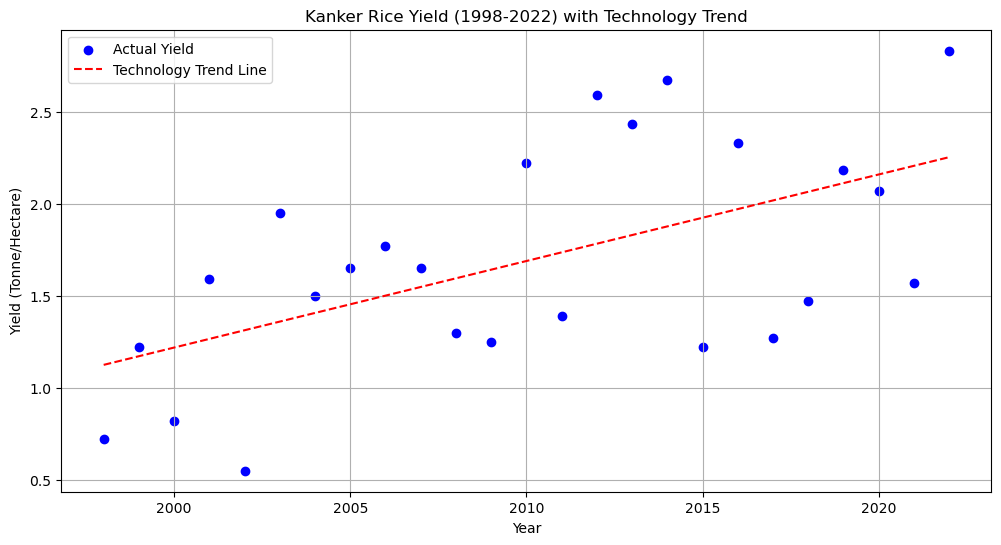

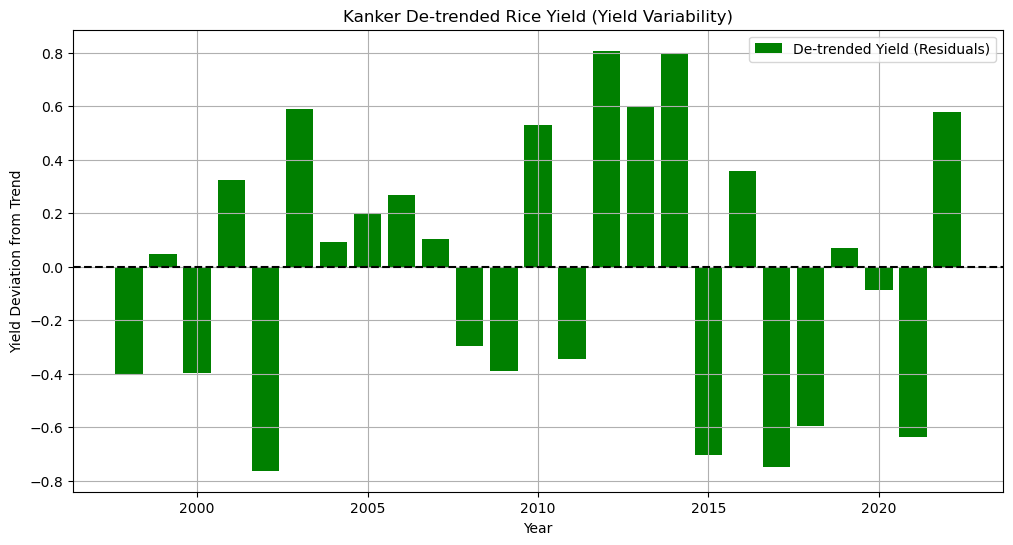


--- Step 2 Complete ---
The second plot (green bars) shows the annual yield variability.
This is the data we will correlate with rainfall in the next step.


In [6]:
# -------------------------------------------------------------------
# STEP 2: DE-TREND THE HISTORICAL YIELD DATA
# -------------------------------------------------------------------
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# --- 1. Define your file names ---
YIELD_FILE_IN = r"C:\Users\Acer\Desktop\Rainfall Index Derivatives\Data\Kanker Rice Data\kanker_yield.csv"
YIELD_FILE_OUT = 'kanker_yield_detrended.csv'

# --- 2. Load the clean yield data ---
print(f"Loading yield data from: {YIELD_FILE_IN}...")
try:
    yield_df = pd.read_csv(YIELD_FILE_IN)
    # Ensure 'Year' is treated as a number
    yield_df['Year'] = pd.to_numeric(yield_df['Year'])
    print("Yield data loaded successfully.")
    print(yield_df.head())
except FileNotFoundError:
    print(f"--- ERROR: File not found: {YIELD_FILE_IN} ---")
    print("Please make sure you have created this file and it is in the same folder.")

# --- 3. Perform the Linear Regression to de-trend ---
print("\nDe-trending the yield data...")
# We need to reshape the 'Year' column to work with scikit-learn
# X = The independent variable (Year)
# y = The dependent variable (Yield)
X = yield_df['Year'].values.reshape(-1, 1)
y = yield_df['Yield'].values

# Create and fit the linear regression model
model = LinearRegression()
model.fit(X, y)

# Get the "trend" line (the predicted values from the model)
trend = model.predict(X)

# Calculate the "residuals"
# Residual = Actual Yield - Predicted (Trend) Yield
residuals = y - trend

# Add the new de-trended data to our DataFrame
yield_df['Trend'] = trend
yield_df['Yield_Detrended'] = residuals

print("De-trending complete.")

# --- 4. Save the de-trended data ---
# We only need to save the Year and the new Residuals
detrended_df_to_save = yield_df[['Year', 'Yield_Detrended']]
detrended_df_to_save.to_csv(YIELD_FILE_OUT, index=False)

print(f"De-trended yield data saved to: {YIELD_FILE_OUT}")

# --- 5. Visualize the result (Highly Recommended) ---
print("\nPlotting the de-trending results...")
plt.figure(figsize=(12, 6))

# Plot the original yield data
plt.scatter(yield_df['Year'], yield_df['Yield'], label='Actual Yield', color='blue')

# Plot the calculated trend line
plt.plot(yield_df['Year'], yield_df['Trend'], label='Technology Trend Line', color='red', linestyle='--')

plt.title('Kanker Rice Yield (1998-2022) with Technology Trend')
plt.xlabel('Year')
plt.ylabel('Yield (Tonne/Hectare)')
plt.legend()
plt.grid(True)
plt.savefig('Index_Gem_plot_1.png', bbox_inches='tight')
plt.show()

# Plot the new, de-trended data (the residuals)
plt.figure(figsize=(12, 6))
plt.bar(yield_df['Year'], yield_df['Yield_Detrended'], label='De-trended Yield (Residuals)', color='green')
plt.axhline(0, color='black', linestyle='--') # Add a zero line
plt.title('Kanker De-trended Rice Yield (Yield Variability)')
plt.xlabel('Year')
plt.ylabel('Yield Deviation from Trend')
plt.legend()
plt.grid(True)
plt.savefig('Index_Gem_plot_2.png', bbox_inches='tight')
plt.show()

print("\n--- Step 2 Complete ---")
print("The second plot (green bars) shows the annual yield variability.")
print("This is the data we will correlate with rainfall in the next step.")

## Optimal Window Selection

### Debugger

In [7]:
# --- DEBUG CELL: Find Column Names ---
import pandas as pd
RAIN_FILE = 'kanker_daily_rain_1997-2024.csv'

# Load just the first 5 rows to see the headers
df_check = pd.read_csv(RAIN_FILE, nrows=5)

print("--- DEBUG OUTPUT ---")
print(f"COLUMNS FOUND IN FILE: {df_check.columns.to_list()}")
print("\nFirst 5 rows of your file:")
print(df_check)

--- DEBUG OUTPUT ---
COLUMNS FOUND IN FILE: ['TIME', 'spatial_ref', 'Mean_Rainfall_mm']

First 5 rows of your file:
         TIME  spatial_ref  Mean_Rainfall_mm
0  1997-01-01            0               0.0
1  1997-01-02            0               0.0
2  1997-01-03            0               0.0
3  1997-01-04            0               0.0
4  1997-01-05            0               0.0


### Main Code

In [8]:
# -------------------------------------------------------------------
# STEP 3: SCIENTIFIC WINDOW SELECTION (FINAL CORRECTED)
# -------------------------------------------------------------------
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from datetime import timedelta
import warnings

# Suppress the specific DeprecationWarning we know about
from pandas.errors import PerformanceWarning
warnings.filterwarnings("ignore", category=DeprecationWarning, 
                        message="Parsing dates involving a day of month without a year specified is ambiguous")


# --- 1. Define File Names and Parameters ---
RAIN_FILE = 'kanker_daily_rain_1997-2024.csv'
YIELD_FILE = 'kanker_yield_detrended.csv'

# --- Make sure this matches your rain CSV ---
DATE_COLUMN_NAME = 'TIME' # (e.g., 'Date', 'time', 'Unnamed: 0')
# ---

# --- Parameters for the search ---
SEASON_START_MONTH = 6
SEASON_START_DAY = 1
SEASON_END_MONTH = 10
SEASON_END_DAY = 31
WINDOW_LENGTHS_TO_TEST = [20, 30, 40, 50, 60]
SPLIT_YEAR = 2016 

# --- 2. Load and Prepare Data ---
print("Loading datasets...")
try:
    rain_df = pd.read_csv(RAIN_FILE, parse_dates=[DATE_COLUMN_NAME])
    rain_df = rain_df.rename(columns={DATE_COLUMN_NAME: 'Date', 'Mean_Rainfall_mm': 'Rainfall'})
    rain_df.set_index('Date', inplace=True)
    yield_df = pd.read_csv(YIELD_FILE)
    yield_df.set_index('Year', inplace=True)
    print("Rainfall and Yield data loaded.")

    # --- 3. Split Data into Training and Test Sets ---
    print(f"Splitting data at {SPLIT_YEAR}...")
    common_years = rain_df.index.year.unique().intersection(yield_df.index)
    rain_df = rain_df[rain_df.index.year.isin(common_years)]
    yield_df = yield_df.loc[common_years]
    yield_train = yield_df[yield_df.index < SPLIT_YEAR]
    yield_test = yield_df[yield_df.index >= SPLIT_YEAR]
    
    print(f"Training on {len(yield_train)} years ({yield_train.index.min()} - {yield_train.index.max()})")
    print(f"Testing on {len(yield_test)} years ({yield_test.index.min()} - {yield_test.index.max()})")

    # --- 4. The Core Function: Calculate Windowed Correlations ---
    def find_correlations(daily_rain, yield_residuals, window_lengths, start_month, start_day, end_month, end_day):
        results = []
        years = yield_residuals.index
        
        if not years.any():
            return pd.DataFrame() # Return empty if no years

        # Use a dummy leap year (2000) for date logic
        test_year = 2000 
        season_start = pd.Timestamp(year=test_year, month=start_month, day=start_day)
        season_end = pd.Timestamp(year=test_year, month=end_month, day=end_day)

        for N in window_lengths:
            search_end_date = season_end - timedelta(days=N-1)
            
            for start_date in pd.date_range(start=season_start, end=search_end_date):
                cumulative_rain_series = []
                valid_years = []
                
                for year in years:
                    win_start = pd.Timestamp(year=year, month=start_date.month, day=start_date.day)
                    win_end = win_start + timedelta(days=N-1)
                    
                    if win_start in daily_rain.index and win_end in daily_rain.index:
                        rain_slice = daily_rain.loc[win_start:win_end]
                        cumulative_rain = rain_slice['Rainfall'].sum()
                        cumulative_rain_series.append(cumulative_rain)
                        valid_years.append(year)
                
                if len(valid_years) > 1:
                    valid_yield_residuals = yield_residuals.loc[valid_years]['Yield_Detrended']
                    corr, p_value = spearmanr(cumulative_rain_series, valid_yield_residuals)
                    
                    results.append({
                        'Window_Length_N': N,
                        'Start_Date_Str': start_date.strftime('%B-%d'), # e.g. "July-09"
                        'Correlation': corr,
                        'p_Value': p_value
                    })

        return pd.DataFrame(results)

    # --- 5. Run the Analysis on the TRAINING Data ---
    print("\n--- Running Analysis on Training Data ---")
    print("This may take a few minutes...")

    train_results_df = find_correlations(
        rain_df, 
        yield_train, 
        WINDOW_LENGTHS_TO_TEST, 
        SEASON_START_MONTH, SEASON_START_DAY, 
        SEASON_END_MONTH, SEASON_END_DAY
    )

    if not train_results_df.empty:
        print("Training analysis complete.")
        best_window_train = train_results_df.loc[train_results_df['Correlation'].abs().idxmax()]
        
        print("\n--- Best Window from Training Data ---")
        print(best_window_train)

        # --- 6. Validate the Winning Window on the TEST Data ---
        print("\n--- Validating Best Window on Test Data ---")
        
        N_WINNER = int(best_window_train['Window_Length_N'])
        START_DATE_STR_WINNER = best_window_train['Start_Date_Str']
        
        # *** THIS IS THE CORRECTED VALIDATION CALL ***
        # We run the function *only* for the winning N=[30]
        # But we run it over the *entire original season*
        validation_df_all_starts = find_correlations(
            rain_df,
            yield_test,
            [N_WINNER],                 # Only the best N
            SEASON_START_MONTH,         # Original season start month (6)
            SEASON_START_DAY,           # Original season start day (1)
            SEASON_END_MONTH,           # Original season end month (10)
            SEASON_END_DAY              # Original season end day (31)
        )

        if not validation_df_all_starts.empty:
            # Now, filter this dataframe to get the ONE row we care about
            validation_row = validation_df_all_starts[
                validation_df_all_starts['Start_Date_Str'] == START_DATE_STR_WINNER
            ]
        
            if not validation_row.empty:
                print("\n--- Validation Result ---")
                print(validation_row)

                # --- 7. Final Recommendation ---
                print("\n\n--- !!! FINAL RECOMMENDATION !!! ---")
                print("Based on this analysis, your scientifically selected Critical Window is:")
                print(f"   Length: {N_WINNER} days")
                print(f"   Start Date: {START_DATE_STR_WINNER}")

                print("\nThis window had the strongest correlation with de-trended yield in the training data.")
                print(f"Training Correlation (rho): {best_window_train['Correlation']:.4f}")
                print(f"Test Set Correlation (rho):   {validation_row['Correlation'].iloc[0]:.4f}")

                if np.sign(best_window_train['Correlation']) == np.sign(validation_row['Correlation'].iloc[0]):
                    print("\nGood News: The correlation sign is consistent in the test set.")
                else:
                    print("\n--- WARNING: The correlation sign flipped in the test set. The window may not be stable. ---")
            else:
                print(f"--- ERROR: Validation failed. Could not find start date '{START_DATE_STR_WINNER}' in test results. ---")
        else:
            print("--- ERROR: Validation failed. No results returned from test set. ---")
    else:
        print("--- ERROR: Training failed. No results generated. Check your data and date ranges. ---")

    print("\n--- Step 3 Complete ---")

except KeyError as e:
    print(f"\n--- !!! KEY ERROR !!! ---")
    print(f"A column name {e} was not found. Check 'DATE_COLUMN_NAME' at the top.")
except Exception as e:
    print(f"\n--- An unexpected error occurred ---")
    print(e)

Loading datasets...
Rainfall and Yield data loaded.
Splitting data at 2016...
Training on 18 years (1998 - 2015)
Testing on 7 years (2016 - 2022)

--- Running Analysis on Training Data ---
This may take a few minutes...
Training analysis complete.

--- Best Window from Training Data ---
Window_Length_N          30
Start_Date_Str      July-09
Correlation        0.909185
p_Value                 0.0
Name: 172, dtype: object

--- Validating Best Window on Test Data ---

--- Validation Result ---
    Window_Length_N Start_Date_Str  Correlation  p_Value
38               30        July-09          0.5  0.25317


--- !!! FINAL RECOMMENDATION !!! ---
Based on this analysis, your scientifically selected Critical Window is:
   Length: 30 days
   Start Date: July-09

This window had the strongest correlation with de-trended yield in the training data.
Training Correlation (rho): 0.9092
Test Set Correlation (rho):   0.5000

Good News: The correlation sign is consistent in the test set.

--- Step 3 

## Creating Final Index Time Series

In [9]:
# -------------------------------------------------------------------
# STEP 4: CREATE THE FINAL INDEX TIME SERIES
# -------------------------------------------------------------------
import pandas as pd
import numpy as np
from datetime import timedelta

# --- 1. Define File Names and Parameters ---
RAIN_FILE = 'kanker_daily_rain_1997-2024.csv'
YIELD_FILE = r"C:\Users\Acer\Desktop\Rainfall Index Derivatives\Data\Kanker Rice Data\kanker_yield.csv" # We use this just to get the list of years
OUTPUT_FILE = 'final_index_series.csv'

# --- !!! YOUR WINNING WINDOW (from Step 3) !!! ---
N_DAYS = 30
START_MONTH = 7
START_DAY = 9
# ---

# --- 2. Load the Daily Rainfall Data ---
print(f"Loading daily rainfall from: {RAIN_FILE}...")
# Find the date column name from your previous step
DATE_COLUMN_NAME = 'TIME' 
rain_df = pd.read_csv(RAIN_FILE, parse_dates=[DATE_COLUMN_NAME])
rain_df = rain_df.rename(columns={DATE_COLUMN_NAME: 'Date', 'Mean_Rainfall_mm': 'Rainfall'})
rain_df.set_index('Date', inplace=True)
print("Rainfall data loaded.")

# --- 3. Load Yield Data to Get Year Range ---
# We'll use this to ensure we only create index values for years
# where we also have yield data (for the backtest).
yield_df = pd.read_csv(YIELD_FILE)
YEARS_TO_PROCESS = yield_df['Year'].unique()
YEARS_TO_PROCESS.sort()

print(f"Will process {len(YEARS_TO_PROCESS)} years: {YEARS_TO_PROCESS.min()} to {YEARS_TO_PROCESS.max()}")

# --- 4. Loop Through Years and Calculate Index Value ---
index_data = [] # This list will hold our results

for year in YEARS_TO_PROCESS:
    # Define the start and end of the window for this year
    win_start = pd.Timestamp(year=year, month=START_MONTH, day=START_DAY)
    win_end = win_start + timedelta(days=N_DAYS - 1)
    
    # Check if this date range is fully present in our rain data
    if win_start in rain_df.index and win_end in rain_df.index:
        # Select the rainfall in this window
        rain_slice = rain_df.loc[win_start:win_end]
        
        # Calculate the cumulative (total) rainfall
        cumulative_rain = rain_slice['Rainfall'].sum()
        
        # Store the result
        index_data.append({
            'Year': year,
            'Index_Value_mm': cumulative_rain
        })
    else:
        print(f"--- WARNING: Missing rainfall data for {year}. Skipping this year. ---")

print("Index calculation complete.")

# --- 5. Create and Save Final DataFrame ---
final_index_df = pd.DataFrame(index_data)
final_index_df.to_csv(OUTPUT_FILE, index=False)

print("\n--- SUCCESS! ---")
print(f"Final index time series saved to: {OUTPUT_FILE}")
print("\nFirst 5 rows of your final index file:")
print(final_index_df.head())
print("\nLast 5 rows of your final index file:")
print(final_index_df.tail())

Loading daily rainfall from: kanker_daily_rain_1997-2024.csv...
Rainfall data loaded.
Will process 25 years: 1998 to 2022
Index calculation complete.

--- SUCCESS! ---
Final index time series saved to: final_index_series.csv

First 5 rows of your final index file:
   Year  Index_Value_mm
0  1998      302.446112
1  1999      364.210995
2  2000      308.890435
3  2001      435.131085
4  2002      204.792493

Last 5 rows of your final index file:
    Year  Index_Value_mm
20  2018      335.504314
21  2019      312.018402
22  2020      197.247845
23  2021      208.972162
24  2022      540.494782
